In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from scipy.stats import gmean

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
criterion_x86 = pd.read_csv('../data/criterion_x86.csv')
criterion_aarch64 = pd.read_csv('../data/criterion_aarch64.csv')

BACKEND_MAP = {'scalar': 'skalarny', 'sse2': 'SSE2', 'avx2': 'AVX2',
               'avx512': 'AVX-512', 'neon': 'NEON'}
FUNCTION_MAP = {'decrypt': 'deszyfrowanie', 'encrypt': 'szyfrowanie',
                'encrypt_inflight': 'szyfrowanie w locie'}

version_order = ['32/64', '48/72', '48/96', '64/96', '64/128',
                 '96/96', '96/144', '128/128', '128/192', '128/256']

def localize(df):
    df = df.copy()
    df['version'] = df['version'].str.replace('_', '/', regex=False)
    df['backend'] = df['backend'].map(BACKEND_MAP).fillna(df['backend'])
    df['function'] = df['function'].map(FUNCTION_MAP).fillna(df['function'])
    return df


criterion_x86 = localize(criterion_x86)
criterion_aarch64 = localize(criterion_aarch64)


In [6]:
def get_speck(df):
    speck = df[df['benchmark'] == 'speck']
    speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
    speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

    speck['keys_per_sec'] = (
            speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
    )
    return speck

In [7]:
speck_x86 = get_speck(criterion_x86)
speck_aarch64 = get_speck(criterion_aarch64)

In [8]:
def regression(df, group_cols):
    results = []

    for keys, group in df.groupby(group_cols):
        x = group['iteration_count'].values
        y = group['sample_measured_value'].values

        if np.ptp(x) == 0:
            per_iter = y / x
            slope = np.mean(per_iter)
            sem = np.std(per_iter, ddof=1) / np.sqrt(len(per_iter))
            ci_low = slope - 1.96 * sem
            ci_high = slope + 1.96 * sem
            intercept = 0.0
            r2 = np.nan
        else:
            slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)

            y_pred = slope * x + intercept
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot

        keys_per_iter = group['throughput_num'].iloc[0]
        keys_per_sec = keys_per_iter / (slope / 1e9)

        results.append({
            **dict(zip(group_cols, keys)),
            'time_per_iter_ns': slope,
            'ci_95_low_ns': ci_low,
            'ci_95_high_ns': ci_high,
            'intercept_ns': intercept,
            'r2': r2,
            'keys_per_sec': keys_per_sec,
            'Mkeys_per_sec': keys_per_sec / 1e6,
        })

    return pd.DataFrame(results)

In [9]:
speck_reg_x86 = regression(speck_x86, ['backend', 'architecture', 'function', 'version'])
speck_reg_aarch64 = regression(speck_aarch64, ['backend', 'architecture', 'function', 'version'])

In [10]:
def fmt_val_pct(x, up, dn):
    if pd.isna(x) or x <= 0:
        return "--"
    if pd.isna(up) or pd.isna(dn):
        return rf"\({x:.2f}\)"
    return rf"\({x:.2f}\,(^{{+{up:.1f}\%}}_{{-{dn:.1f}\%}})\)"


def make_speck_latex_pivot(df, backend_order):
    d = df.copy()
    d['up_pct'] = (d['time_per_iter_ns'] / d['ci_95_low_ns'] - 1.0) * 100
    d['dn_pct'] = (1.0 - d['time_per_iter_ns'] / d['ci_95_high_ns']) * 100
    d['cell'] = [fmt_val_pct(x, up, dn)
                 for x, up, dn in zip(d['Mkeys_per_sec'], d['up_pct'], d['dn_pct'])]

    pivot = d.pivot_table(
        index=['backend', 'version'],
        columns='function',
        values='cell',
        aggfunc='first',
    ).reset_index()
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

In [11]:
speck_latex_x86 = make_speck_latex_pivot(speck_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'])
speck_latex_x86.to_csv("../csv/speck_results_x86.csv", index=False)

In [12]:
speck_latex_aarch64 = make_speck_latex_pivot(speck_reg_aarch64, ['skalarny', 'NEON'])
speck_latex_aarch64.to_csv("../csv/speck_results_x86.csv", index=False)

In [13]:
def make_speck_combined_mean(reg_specs):
    funcs = ['deszyfrowanie', 'szyfrowanie', 'szyfrowanie w locie']
    vals, ups, dns = [], [], []

    for reg_df, backend_order, arch in reg_specs:
        d = reg_df[reg_df['function'].isin(funcs)].copy()
        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['backend', 'function'])[['mkeys', 'mkeys_lo', 'mkeys_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['mkeys_hi'] / g['mkeys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['mkeys_lo'] / g['mkeys']) * 100

        def piv(col):
            p = g.pivot(index='backend', columns='function', values=col)
            p.columns.name = None
            p = p.reindex(columns=funcs)
            p.index = pd.Categorical(p.index, categories=backend_order, ordered=True)
            p = p.sort_index()
            return p.rename(index={b: (f"{b}\n({arch})" if b == 'skalarny' else b)
                                   for b in p.index})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals).T
    up = pd.concat(ups).T
    dn = pd.concat(dns).T
    return val, up, dn

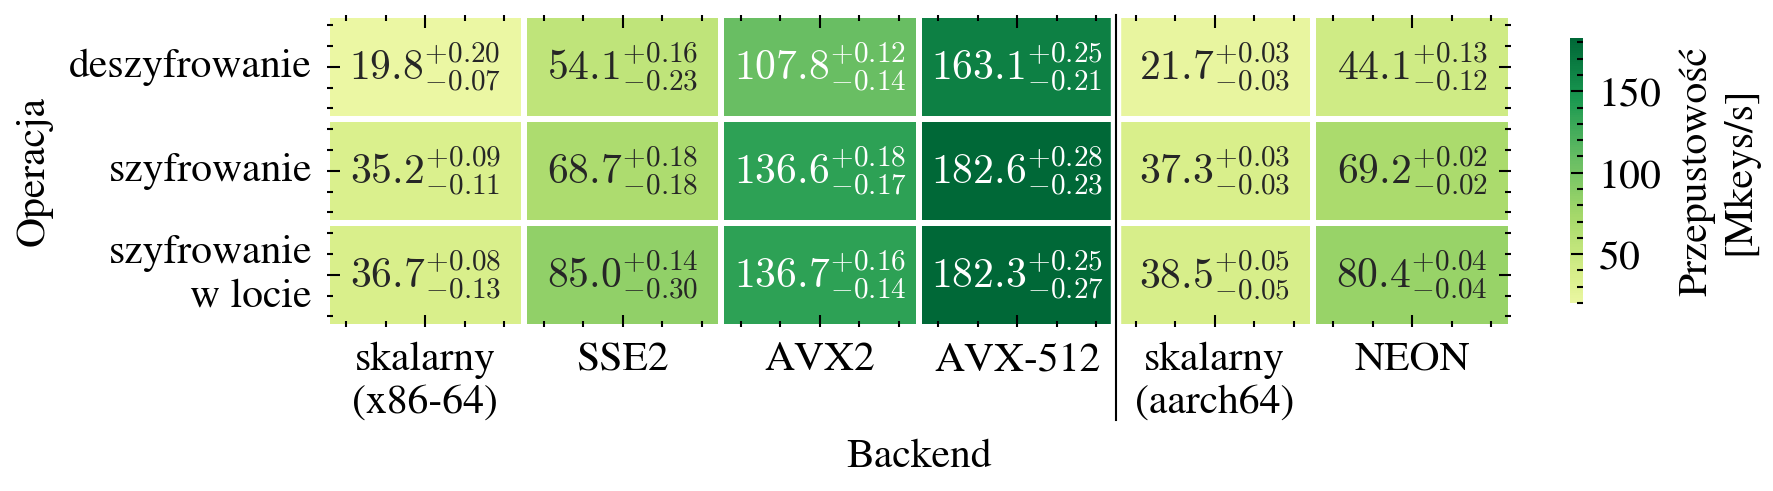

In [14]:
def plot_speck_heatmap_combined(reg_specs, filename, width):
    val, up, dn = make_speck_combined_mean(reg_specs)
    val = val.rename(index={'szyfrowanie w locie': 'szyfrowanie\nw locie'})

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, dd = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(dd):
                annot[i, j] = rf"${v:.2f}$"
            else:
                annot[i, j] = rf"${v:.1f}^{{+{u:.2f}}}_{{-{dd:.2f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.axvline(x=4, color='white', linewidth=2.5)
        ax.plot([4, 4], [0, val.shape[0] + 0.9], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel("Backend")
        ax.set_ylabel('Operacja')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_speck_heatmap_combined(
    [
        (speck_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (speck_reg_aarch64, ['skalarny', 'NEON'], 'aarch64'),
    ],
    'speck_pivot_backend_heatmap_combined.svg',
    FIG_WIDTH,
)

In [15]:
speck_inflight_x86 = speck_reg_x86[speck_reg_x86['function'] == 'szyfrowanie w locie']
speck_inflight_aarch64 = speck_reg_aarch64[speck_reg_aarch64['function'] == 'szyfrowanie w locie']

In [16]:
def make_speck_backend_speedup(df, backend_order, fmt=False):
    d = df.copy()
    d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
    d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

    sc = d[d['backend'] == 'skalarny'].set_index('version')
    sc_k = sc['keys_per_sec']
    sc_lo = sc['k_lo']
    sc_hi = sc['k_hi']

    s = d[d['backend'] != 'skalarny'].copy()
    s['speedup'] = s['keys_per_sec'] / s['version'].map(sc_k)
    s['sp_hi'] = s['k_hi'] / s['version'].map(sc_lo)
    s['sp_lo'] = s['k_lo'] / s['version'].map(sc_hi)
    s['up_pct'] = (s['sp_hi'] / s['speedup'] - 1.0) * 100
    s['dn_pct'] = (1.0 - s['sp_lo'] / s['speedup']) * 100

    s['backend'] = pd.Categorical(s['backend'], categories=backend_order, ordered=True)
    s['version'] = pd.Categorical(s['version'], categories=version_order, ordered=True)

    def piv(col):
        p = s.pivot_table(index='version', columns='backend', values=col, observed=True).reset_index()
        p.columns.name = None
        p['version'] = p['version'].astype(str).str.replace('_', '/', regex=False)
        return p.set_index('version')

    if fmt == 'ci':
        return piv('speedup'), piv('up_pct'), piv('dn_pct')
    return piv('speedup')

In [17]:
def merge_ci(x86, aarch64):
    return tuple(pd.merge(a, b, on='version', how='left') for a, b in zip(x86, aarch64))

sp_x86 = make_speck_backend_speedup(speck_inflight_x86, ['SSE2', 'AVX2', 'AVX-512'], fmt='ci')
sp_arm = make_speck_backend_speedup(speck_inflight_aarch64, ['NEON'], fmt='ci')
speck_backend_speedup_ci = merge_ci(sp_x86, sp_arm)

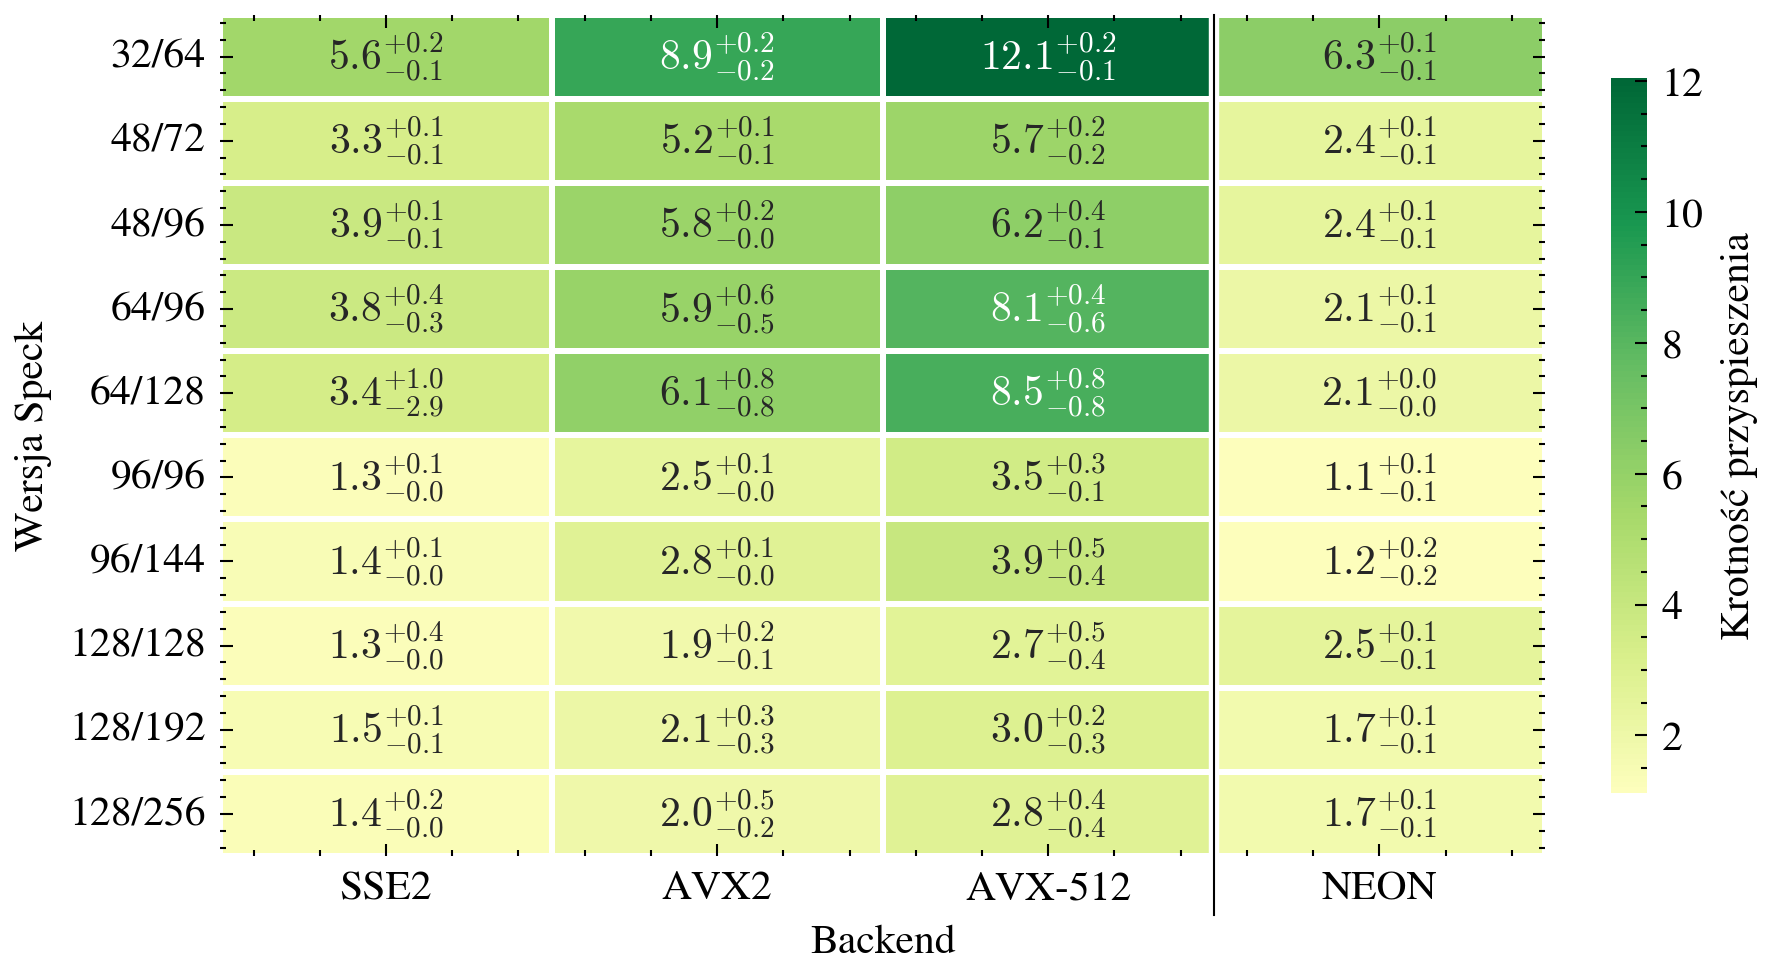

In [18]:
def plot_speck_backend_speedup(speedup_ci, filename, fig_height):
    val, up, dn = speedup_ci
    data = val

    annot = np.empty(data.shape, dtype=object)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${v:.2f}$"
            else:
                annot[i, j] = rf"${v:.1f}^{{+{u:.1f}}}_{{-{d_:.1f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            annot=annot,
            fmt='',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': 'Krotność przyspieszenia', 'shrink': 0.85},
        )

        ax.set_xlabel('Backend')
        ax.set_ylabel('Wersja Speck')

        ax.axvline(x=3, color='white', linewidth=2.5)
        ax.plot([3, 3], [0, val.shape[0] + 0.7], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_speck_backend_speedup(speck_backend_speedup_ci, 'speck_backend_speedup.svg', FIG_HEIGHT_3)

In [19]:
def get_engine(df):
    engine = df[df['benchmark'] == 'engine']
    engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type', 'function'])
    engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

    engine['keys_per_sec'] = (
            engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
    )

    return engine

In [20]:
engine_x86 = get_engine(criterion_x86)
engine_aarch64 = get_engine(criterion_aarch64)

In [21]:
engine_reg_x86 = regression(engine_x86, ['backend', 'architecture', 'version', 'suffix'])
engine_reg_aarch64 = regression(engine_aarch64, ['backend', 'architecture', 'version', 'suffix'])

In [22]:
def fmt_val_pct(x, up, dn):
    if pd.isna(x) or x <= 0:
        return "--"
    if pd.isna(up) or pd.isna(dn):
        return rf"\({x:.2f}\)"
    return rf"\({x:.2f}\,(^{{+{up:.1f}\%}}_{{-{dn:.1f}\%}})\)"


def make_engine_latex_pivot(df, backend_order):
    d = df.copy()
    d['up_pct'] = (d['time_per_iter_ns'] / d['ci_95_low_ns'] - 1.0) * 100
    d['dn_pct'] = (1.0 - d['time_per_iter_ns'] / d['ci_95_high_ns']) * 100
    d['cell'] = [fmt_val_pct(x, up, dn)
                 for x, up, dn in zip(d['Mkeys_per_sec'], d['up_pct'], d['dn_pct'])]

    pivot = (d.pivot_table(index=['backend', 'version'], columns='suffix',
                           values='cell', aggfunc='first')
             .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
             .reset_index())
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)


engine_latex_x86 = make_engine_latex_pivot(engine_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'])
engine_latex_x86.to_csv("../csv/engine_results_x86.csv", index=False)

engine_latex_aarch64 = make_engine_latex_pivot(engine_reg_aarch64, ['skalarny', 'NEON'])
engine_latex_aarch64.to_csv("../csv/engine_results_aarch64.csv", index=False)

In [23]:
def make_engine_combined_mean(reg_specs):
    suffixes = [1.0, 2.0, 3.0]
    vals, ups, dns = [], [], []

    for reg_df, backend_order, arch in reg_specs:
        d = reg_df[reg_df['suffix'].isin(suffixes)].copy()
        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['backend', 'suffix'])[['mkeys', 'mkeys_lo', 'mkeys_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['mkeys_hi'] / g['mkeys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['mkeys_lo'] / g['mkeys']) * 100

        def piv(col):
            p = g.pivot(index='backend', columns='suffix', values=col)
            p = p.rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
            p.columns.name = None
            p = p.reindex(columns=['1', '2', '3'])
            p.index = pd.Categorical(p.index, categories=backend_order, ordered=True)
            p = p.sort_index()
            return p.rename(index={b: (f"{b}\n({arch})" if b == 'skalarny' else b)
                                   for b in p.index})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals).T
    up = pd.concat(ups).T
    dn = pd.concat(dns).T
    return val, up, dn

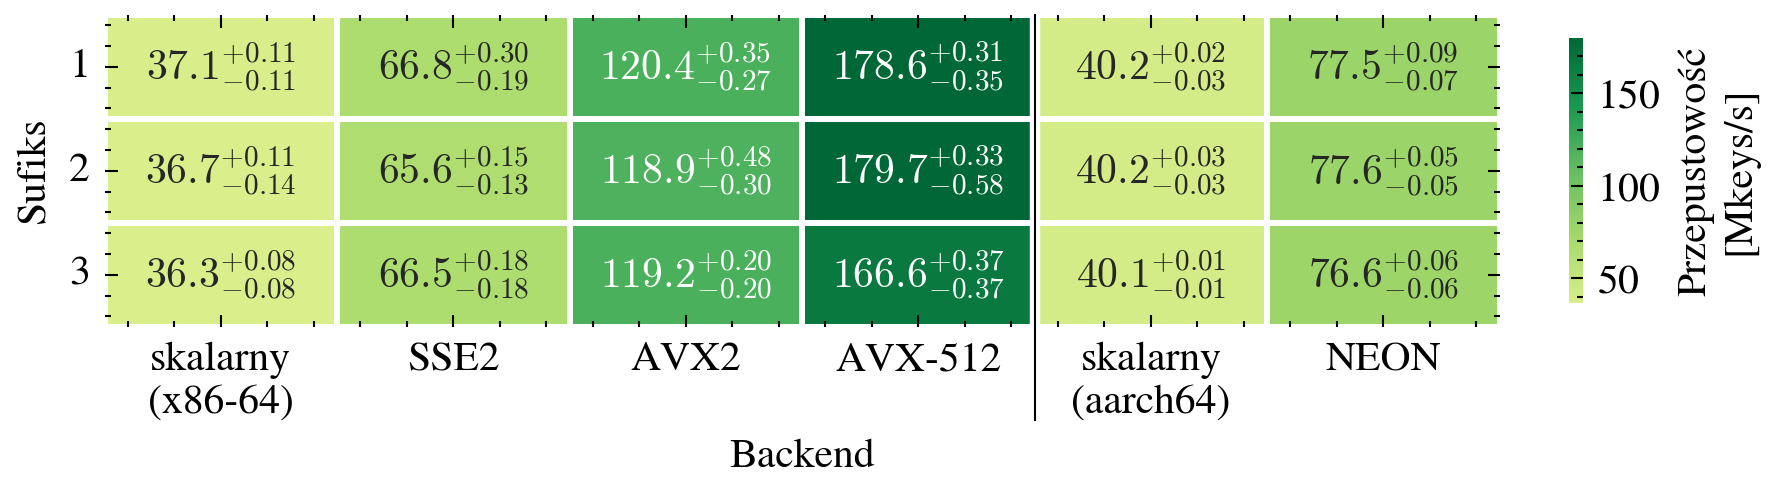

In [24]:
def plot_engine_heatmap_combined(reg_specs, filename, width):
    val, up, dn = make_engine_combined_mean(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${v:.2f}$"
            else:
                annot[i, j] = rf"${v:.1f}^{{+{u:.2f}}}_{{-{d_:.2f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.axvline(x=4, color='white', linewidth=2.5)
        ax.plot([4, 4], [0, val.shape[0] + 0.9], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Backend')
        ax.set_ylabel('Sufiks')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_engine_heatmap_combined(
    [
        (engine_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (engine_reg_aarch64, ['skalarny', 'NEON'], 'aarch64'),
    ],
    'engine_pivot_backend_heatmap_combined.svg',
    FIG_WIDTH,
)

In [25]:
def make_engine_single_backend_combined(reg_specs):
    vals, ups, dns = [], [], []

    for reg_df, arch, backend, label in reg_specs:
        d = reg_df[(reg_df['architecture'] == arch) &
                   (reg_df['backend'] == backend)].copy()

        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']
        d['up_pct'] = (d['mkeys_hi'] / d['mkeys'] - 1.0) * 100
        d['dn_pct'] = (1.0 - d['mkeys_lo'] / d['mkeys']) * 100

        def piv(col):
            p = (d.pivot_table(index='version', columns='suffix', values=col)
                 .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
                 .reset_index())
            p.columns.name = None
            p['version'] = pd.Categorical(p['version'], categories=version_order, ordered=True)
            p = p.sort_values('version').reset_index(drop=True)
            p = p.set_index('version')[['1', '2', '3']]
            # label tylko przy sufiksie 1
            return p.rename(columns={s: (f"{s}\n({label})" if s == '1' else s) for s in p.columns})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals, axis=1)
    up = pd.concat(ups, axis=1)
    dn = pd.concat(dns, axis=1)
    return val, up, dn

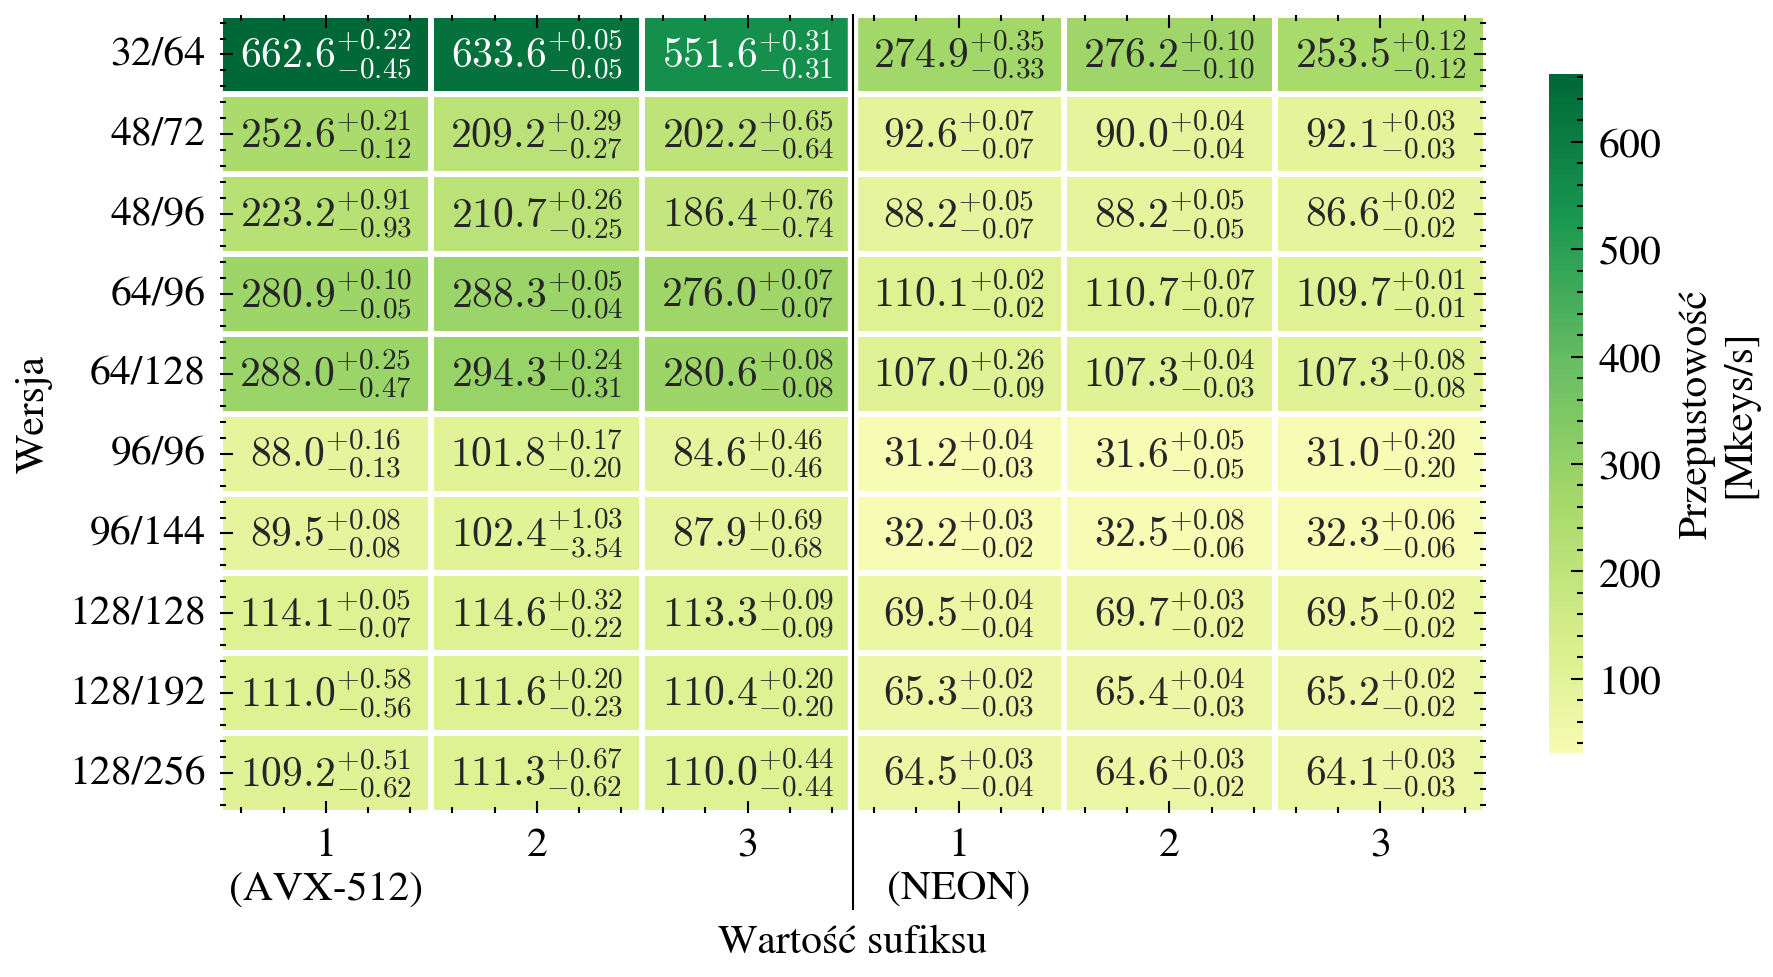

In [26]:
def plot_engine_single_backend_combined(reg_specs, filename):
    val, up, dn = make_engine_single_backend_combined(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${v:.1f}$"
            else:
                annot[i, j] = rf"${v:.1f}^{{+{u:.2f}}}_{{-{d_:.2f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_3), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.axvline(x=3, color='white', linewidth=2.5)
        ax.plot([3, 3], [0, val.shape[0] + 1.2], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Wartość sufiksu')
        ax.set_ylabel('Wersja')


        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_engine_single_backend_combined(
    [
        (engine_reg_x86, 'x86_64', 'AVX-512', 'AVX-512'),
        (engine_reg_aarch64, 'aarch64', 'NEON', 'NEON'),
    ],
    'engine_pivot_backend_single_combined.svg',
)